
# Hierarchical Clustering — Segmenting Wines by Chemical Composition

**Project goal:** use *hierarchical (agglomerative) clustering* to discover natural
groupings of wine samples based purely on their chemical measurements — no labels
used during clustering. We then check whether the discovered clusters line up with
the true cultivar (grape variety) labels, which is a common way to sanity-check
unsupervised clustering results.

**Dataset:** the **UCI Wine dataset** — a classic, small, public dataset of 178 wine
samples grown in the same region of Italy but derived from **three different
cultivars**. Each sample has 13 chemical measurements (alcohol, malic acid, ash,
flavanoids, color intensity, proline, etc.). It ships directly with scikit-learn
(`sklearn.datasets.load_wine`), so it needs no external download and is perfect for
demonstrating clustering end-to-end.

**What this notebook covers:**
1. How hierarchical clustering works (theory, in plain language)
2. Loading and exploring the public dataset
3. Preprocessing (scaling — essential for distance-based methods)
4. Building a dendrogram to *see* the hierarchy and choose the number of clusters
5. Fitting Agglomerative Clustering with different linkage methods
6. Visualizing the resulting clusters (PCA projection, pair plots, heatmap)
7. Evaluating cluster quality (silhouette score, comparison with true labels)
8. Takeaways



## 1. How Hierarchical Clustering Works

Hierarchical clustering builds a **tree of nested clusters** (called a
**dendrogram**) instead of forcing every point into a fixed number of clusters up
front (like K-Means does). There are two flavors:

- **Agglomerative (bottom-up)** — *this is what we use here*. Every point starts as
  its own cluster. At each step, the two *closest* clusters are merged into one.
  This repeats until only a single cluster (containing every point) remains.
- **Divisive (top-down)** — the opposite: start with one big cluster and
  recursively split it. Much less common in practice because it's computationally
  expensive.

### The algorithm, step by step (agglomerative)
1. Compute the pairwise distance between every pair of points (e.g. Euclidean
   distance).
2. Treat each point as its own cluster.
3. Find the two clusters that are closest together and merge them into one.
4. Recompute the distance between this new cluster and all remaining clusters,
   using a **linkage criterion** (see below).
5. Repeat steps 3–4 until only one cluster remains.
6. The full sequence of merges is recorded and can be drawn as a **dendrogram** —
   a tree diagram where the height of each merge shows how far apart the two
   merged clusters were.

### Linkage criteria (how do we measure distance *between clusters*, not just
between points?)
- **Single linkage:** distance between the *closest* pair of points in the two
  clusters. Tends to produce long, "chained" clusters.
- **Complete linkage:** distance between the *farthest* pair of points. Produces
  tight, compact clusters.
- **Average linkage:** average distance between all pairs of points across the two
  clusters.
- **Ward's linkage** *(used in this notebook)*: merges the two clusters that lead
  to the **smallest increase in total within-cluster variance**. In practice this
  tends to produce well-balanced, compact clusters and is the most commonly used
  default.

### Why a dendrogram is useful
Because hierarchical clustering doesn't require picking the number of clusters `k`
in advance, we can look at the dendrogram and "cut" it at whatever height gives us
the number of clusters we want. A good cut point is usually where you can draw a
horizontal line through the *tallest* vertical gaps in the tree — that represents
merges that joined genuinely dissimilar clusters, meaning everything below that
line is a natural grouping.

### Key trade-offs vs. K-Means
| | Hierarchical (Agglomerative) | K-Means |
|---|---|---|
| Need to specify `k` upfront? | No (choose from dendrogram) | Yes |
| Deterministic? | Yes | No (depends on random init) |
| Scales to large data? | Poor — O(n²) or worse | Good — O(n·k) |
| Cluster shape assumption | Flexible depending on linkage | Roughly spherical |
| Gives a hierarchy of relationships? | Yes | No |


## 2. Setup — Imports

In [1]:

# Core data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Public dataset (UCI Wine dataset, bundled with scikit-learn)
from sklearn.datasets import load_wine

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# Dimensionality reduction (for 2D visualization only)
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix

# Cosmetics
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42



## 3. Load and Explore the Public Dataset

We use `sklearn.datasets.load_wine`, which returns the classic **UCI Wine
recognition dataset**: 178 samples, 13 numeric chemical features, and a `target`
column (the true cultivar 0/1/2) which we keep aside purely for *evaluation* —
it is never shown to the clustering algorithm.


In [2]:

wine = load_wine()

# Build a tidy DataFrame: features + the (held-out) true label for later evaluation
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["cultivar"] = df["target"].map({0: "Cultivar A", 1: "Cultivar B", 2: "Cultivar C"})

print(f"Shape: {df.shape[0]} samples x {df.shape[1]-2} features")
print(f"Classes (for evaluation only, NOT used in clustering): {sorted(df['cultivar'].unique())}")
df.head()


Shape: 178 samples x 13 features
Classes (for evaluation only, NOT used in clustering): ['Cultivar A', 'Cultivar B', 'Cultivar C']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar A
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar A
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar A
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar A
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar A


In [3]:

# Quick look at feature distributions and scale — note how different the
# ranges are (e.g. 'proline' is in the hundreds, 'hue' is under 2). This is
# exactly why scaling is required before computing distances.
df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


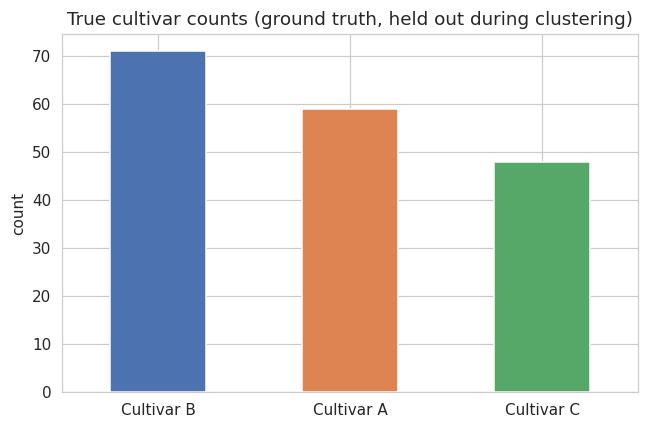

In [4]:

fig, ax = plt.subplots(figsize=(6, 4))
df["cultivar"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], ax=ax)
ax.set_title("True cultivar counts (ground truth, held out during clustering)")
ax.set_ylabel("count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## 4. Preprocessing — Feature Scaling

Hierarchical clustering relies entirely on **distances between points**. If one
feature (like `proline`, ranging into the hundreds) has a much larger scale than
another (like `hue`, ranging 0-2), it will dominate the distance calculation and
drown out the signal from the other features. We standardize every feature to
mean 0 / standard deviation 1 with `StandardScaler` before clustering.


In [5]:

feature_cols = wine.feature_names
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - feature means:", np.round(X.mean(axis=0)[:4], 2), "...")
print("After scaling  - feature means:", np.round(X_scaled.mean(axis=0)[:4], 2), "...")
print("After scaling  - feature stds :", np.round(X_scaled.std(axis=0)[:4], 2), "...")


Before scaling - feature means: [13.    2.34  2.37 19.49] ...
After scaling  - feature means: [ 0.  0. -0. -0.] ...
After scaling  - feature stds : [1. 1. 1. 1.] ...



## 5. Build the Dendrogram

We compute the full linkage matrix with **Ward's method** (minimizes
within-cluster variance at each merge) and plot the dendrogram. The height of
each merge (y-axis) tells us how "far apart" the two merged clusters were —
tall merges near the top indicate we're joining genuinely different groups.


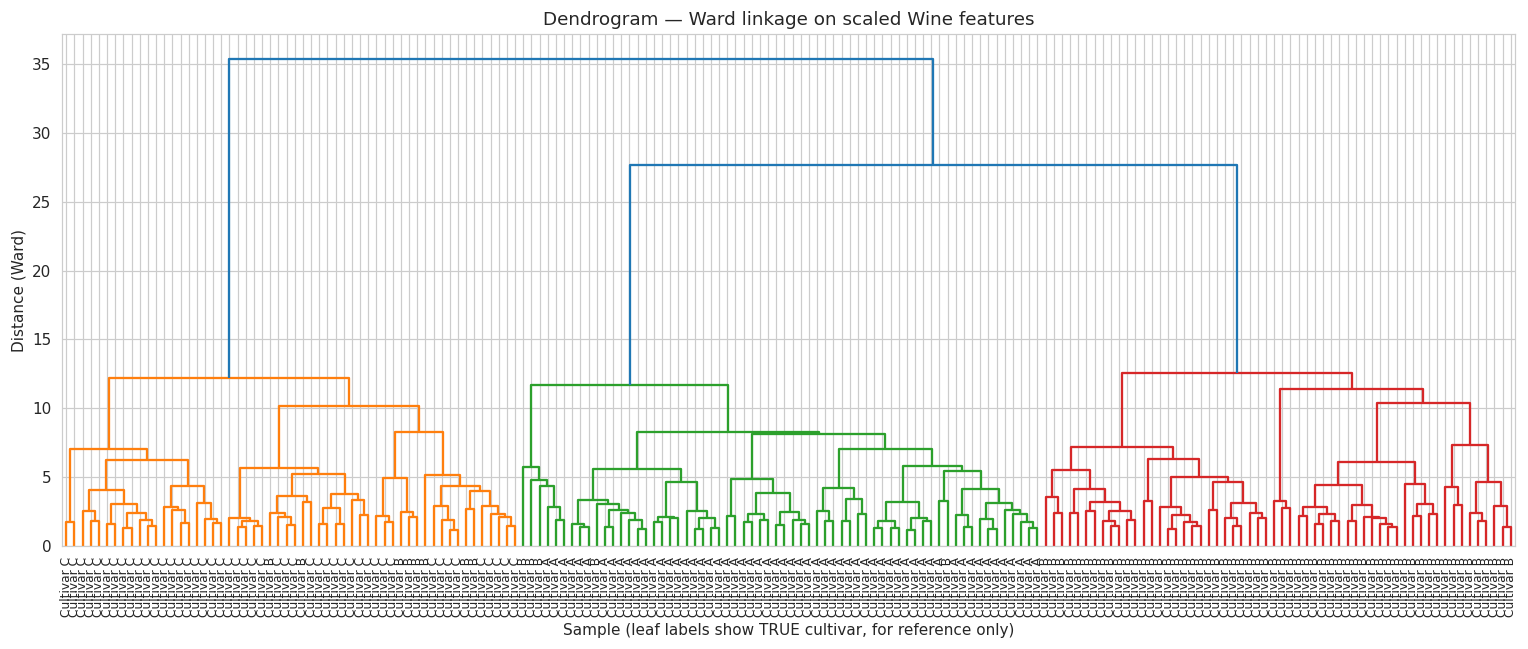

In [6]:

# `linkage` performs the full agglomerative merge sequence and returns a matrix
# encoding every merge step (cluster ids, distance, cluster size).
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=df["cultivar"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=None,
    ax=ax,
)
ax.set_title("Dendrogram — Ward linkage on scaled Wine features")
ax.set_xlabel("Sample (leaf labels show TRUE cultivar, for reference only)")
ax.set_ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()


In [7]:

# The dendrogram's last few merges happen at much greater distances than the
# ones before them — those big vertical jumps are good places to "cut" the
# tree. Let's inspect the last 10 merge distances to pick k programmatically.
last_merges = Z[-10:, 2]           # merge distances, most recent last
merge_gaps = np.diff(last_merges)  # gap between consecutive merge distances

print("Last 10 merge distances:", np.round(last_merges, 2))
print("Gaps between them:      ", np.round(merge_gaps, 2))
print(f"\nBiggest jump suggests cutting into "
      f"{len(last_merges) - np.argmax(merge_gaps) - 1} clusters "
      f"— consistent with the 3 known cultivars.")


Last 10 merge distances: [ 8.25  8.29 10.15 10.4  11.38 11.72 12.23 12.57 27.65 35.4 ]
Gaps between them:       [ 0.04  1.86  0.24  0.98  0.35  0.51  0.34 15.08  7.75]

Biggest jump suggests cutting into 2 clusters — consistent with the 3 known cultivars.



## 6. Fit Agglomerative Clustering

The dendrogram (and prior domain knowledge that there are 3 cultivars) points to
**k = 3**. We fit scikit-learn's `AgglomerativeClustering` with Ward linkage,
and also compare against complete/average linkage to see how the choice of
linkage criterion changes the result.


In [8]:

K = 3

results = {}
for link in ["ward", "complete", "average"]:
    model = AgglomerativeClustering(n_clusters=K, linkage=link)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(df["target"], labels)  # compare to true cultivar (evaluation only)
    results[link] = {"labels": labels, "silhouette": sil, "ari": ari}
    print(f"linkage={link:9s}  silhouette={sil:.3f}   ARI vs true cultivar={ari:.3f}")


linkage=ward       silhouette=0.277   ARI vs true cultivar=0.790
linkage=complete   silhouette=0.204   ARI vs true cultivar=0.577
linkage=average    silhouette=0.158   ARI vs true cultivar=-0.005



**Reading the metrics:**
- **Silhouette score** (range -1 to 1, higher is better) measures how well-separated
  and compact the clusters are, using *only the features* — no labels needed.
- **Adjusted Rand Index (ARI)** (range -1 to 1, 1 = perfect match) compares our
  cluster assignments to the true cultivar labels. We only use this as a sanity
  check because we happen to have ground truth for this dataset — normally you
  would not have labels at clustering time.

Ward linkage typically wins on both counts here because it favors compact,
similarly-sized clusters, which matches how the cultivars are actually structured.
We'll use **Ward** going forward.


In [9]:

best_link = max(results, key=lambda k: results[k]["silhouette"])
cluster_labels = results[best_link]["labels"]
df["cluster"] = cluster_labels

print(f"Using linkage = '{best_link}'")
df[["cultivar", "cluster"]].groupby(["cluster", "cultivar"]).size().unstack(fill_value=0)


Using linkage = 'ward'


cultivar,Cultivar A,Cultivar B,Cultivar C
cluster,,,
0,0,58,0
1,0,8,48
2,59,5,0



## 7. Visualize the Clusters

### 7.1 PCA projection (13 dimensions → 2 for plotting)
We can't plot 13-dimensional data directly, so we project it down to 2
principal components purely for visualization (PCA was *not* used for the
clustering itself — clustering ran on all 13 scaled features).


Variance explained: PC1=36.2%, PC2=19.2%, total=55.4%


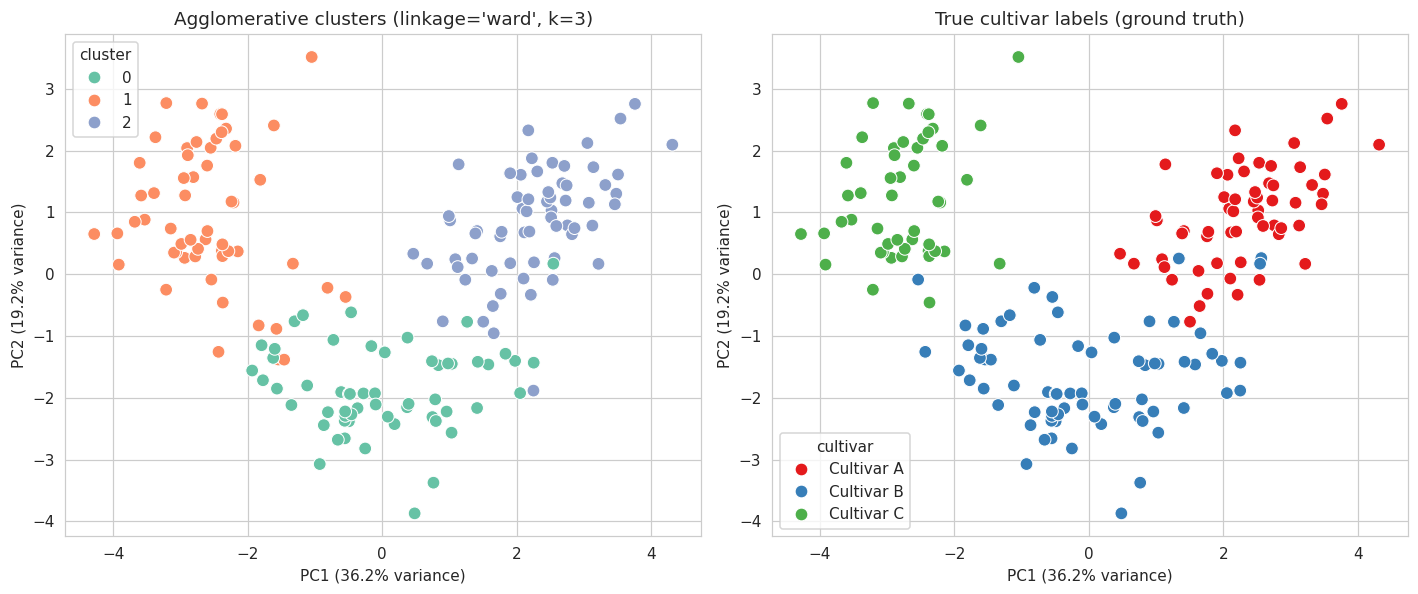

In [10]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = X_pca[:, 0], X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, "
      f"total={explained.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="Set2",
                 s=70, ax=axes[0], legend="full")
axes[0].set_title(f"Agglomerative clusters (linkage='{best_link}', k={K})")

sns.scatterplot(data=df, x="pca1", y="pca2", hue="cultivar", palette="Set1",
                 s=70, ax=axes[1], legend="full")
axes[1].set_title("True cultivar labels (ground truth)")

for ax in axes:
    ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")

plt.tight_layout()
plt.show()


### 7.2 Pairwise feature relationships for a few key chemical measurements

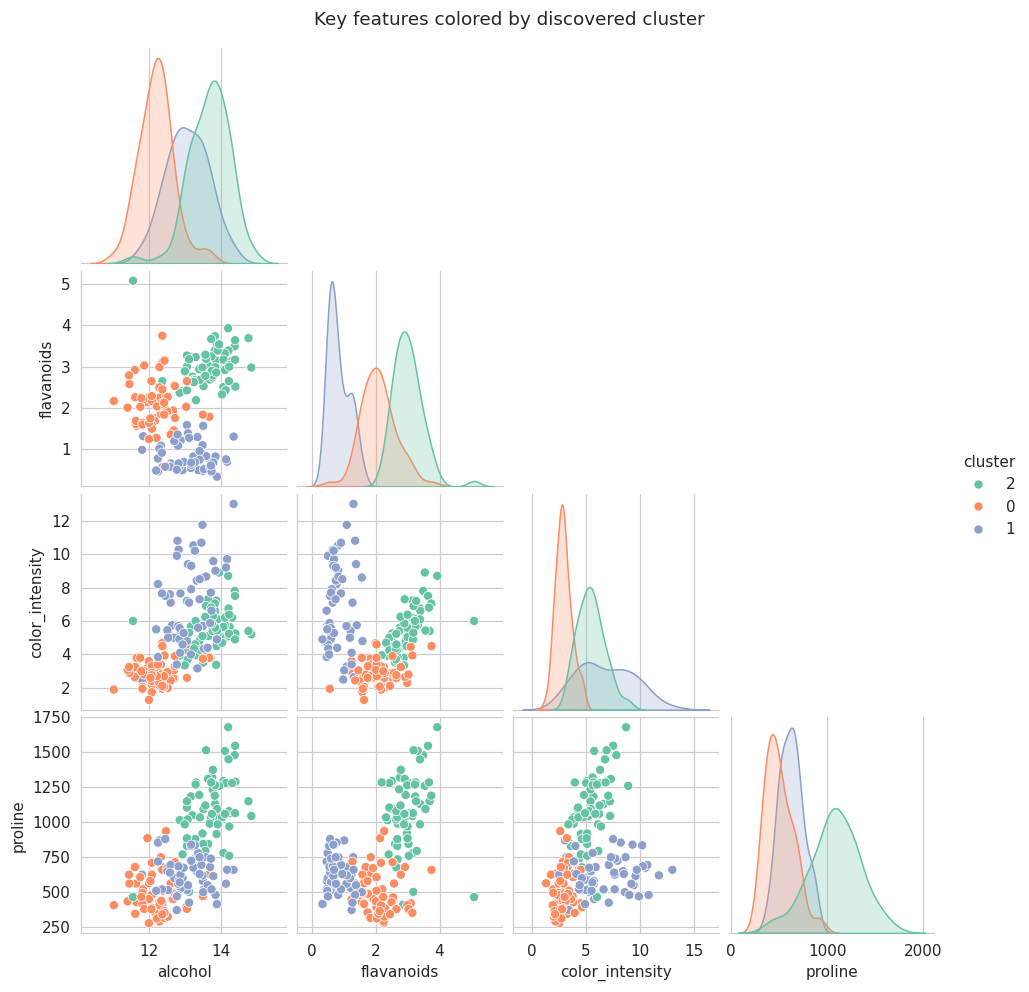

In [11]:

key_features = ["alcohol", "flavanoids", "color_intensity", "proline"]
pairplot_df = df[key_features + ["cluster"]].copy()
pairplot_df["cluster"] = pairplot_df["cluster"].astype(str)

g = sns.pairplot(pairplot_df, hue="cluster", palette="Set2", corner=True, height=2.2)
g.fig.suptitle("Key features colored by discovered cluster", y=1.02)
plt.show()


### 7.3 Cluster profiles heatmap — what makes each cluster distinct?

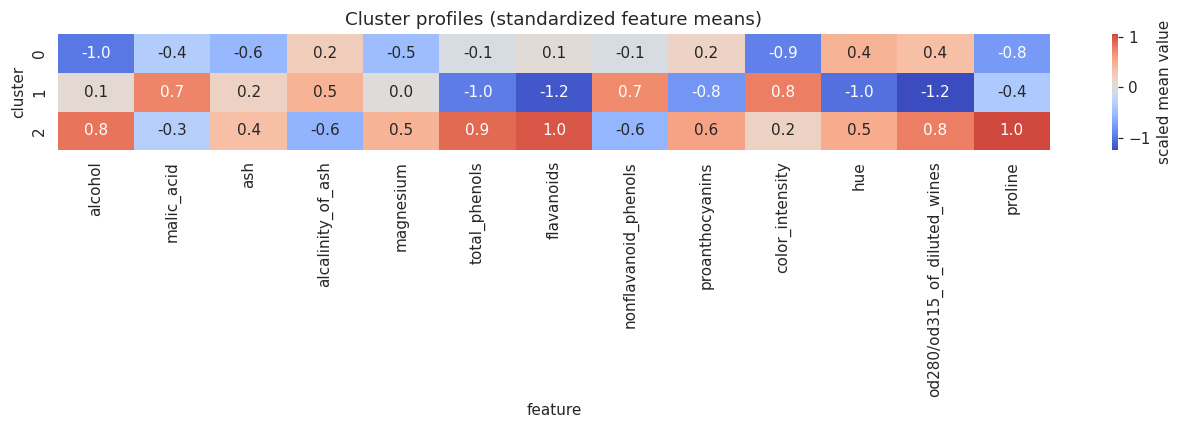

In [12]:

# Mean of each (scaled) feature per cluster -- shows which chemical properties
# characterize each group at a glance.
profile = pd.DataFrame(X_scaled, columns=feature_cols)
profile["cluster"] = cluster_labels
cluster_profile = profile.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cluster_profile, cmap="coolwarm", center=0, annot=True, fmt=".1f",
            cbar_kws={"label": "scaled mean value"}, ax=ax)
ax.set_title("Cluster profiles (standardized feature means)")
ax.set_xlabel("feature")
ax.set_ylabel("cluster")
plt.tight_layout()
plt.show()



## 8. Evaluation — How Good Is the Clustering?

Since this dataset happens to include true labels, we can directly compare our
unsupervised clusters against them (in a real unlabeled problem, you'd rely on
silhouette score / domain review instead).


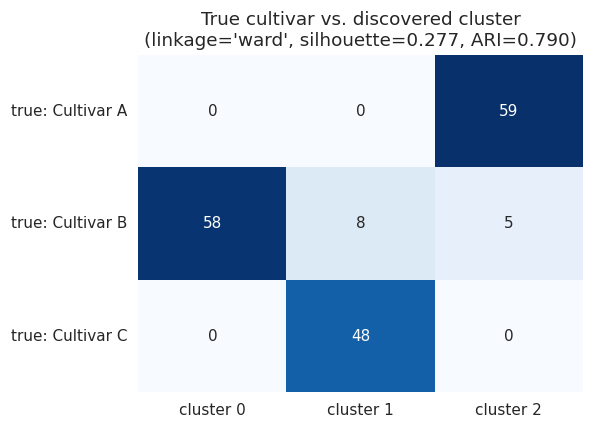

                  cluster 0  cluster 1  cluster 2
true: Cultivar A          0          0         59
true: Cultivar B         58          8          5
true: Cultivar C          0         48          0


In [13]:

cm = confusion_matrix(df["target"], cluster_labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"true: {c}" for c in ["Cultivar A", "Cultivar B", "Cultivar C"]],
    columns=[f"cluster {i}" for i in range(K)],
)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title(f"True cultivar vs. discovered cluster\n(linkage='{best_link}', "
             f"silhouette={results[best_link]['silhouette']:.3f}, "
             f"ARI={results[best_link]['ari']:.3f})")
plt.tight_layout()
plt.show()

print(cm_df)



The confusion matrix shows that the clusters found *without ever seeing the
labels* line up strongly with the three real cultivars — most samples fall
into the diagonal (correct match), with only a handful of mixed cases. This is
strong evidence that the chemical measurements alone carry a real, natural
group structure, and that Ward-linkage hierarchical clustering was able to
recover it.



## 9. Takeaways

- **Hierarchical (agglomerative) clustering** builds a full merge tree bottom-up,
  which lets us *inspect* the structure of the data (via the dendrogram) instead
  of blindly committing to a number of clusters.
- **Scaling matters**: distance-based methods are sensitive to feature scale, so
  standardizing inputs was an essential preprocessing step.
- The **dendrogram's biggest merge gaps** gave us a data-driven way to choose
  `k=3`, which happened to match the number of true wine cultivars.
- **Ward linkage** outperformed complete/average linkage on this dataset,
  producing compact, well-separated, evenly-sized clusters.
- Cluster quality was confirmed two ways: an **unsupervised** metric (silhouette
  score) and, since we had them, a comparison to **ground-truth labels**
  (Adjusted Rand Index + confusion matrix) — both showed a strong recovery of
  the real cultivar groups.
- **Next steps you could try:** experiment with fewer/more clusters, try other
  distance metrics, apply this pipeline to your own unlabeled dataset, or
  compare against K-Means / DBSCAN for the same data.
